# Subset Final Recommender Notebook

## Goal
Take the strongest models from `subset-05-ml-prediction.ipynb`, tune them more
carefully, validate them with stronger cross-validation, lock-in a single
production-ready model per resource, expose the features that drive each
recommendation, and finally show a deployment-style recommendation that a
developer would see before submitting a job.

## Scope (mapped to the issue)
1. **Hyperparameter tuning** of the strongest Subset-05 candidates
   (Random Forest / XGBoost for CPU, XGBoost for memory).
2. **Cross-validation** with `TimeSeriesSplit` and `GroupKFold` (grouped on
   `recurrence_key`) — report mean and variance across folds.
3. **Final model lock-in** for CPU and memory (refit on full training data).
4. **Feature importance / explainability** charts for both models.
5. **Developer-facing recommendation simulation** that turns a single job's
   metadata + history into a CPU/memory recommendation, a confidence tier,
   and an expected violation-risk label — i.e. what TraceAdvisor would show
   the user.

## Inputs (produced by earlier notebooks)
- `job_metrics_train_v0.parquet`
- `job_metrics_val_with_baselines_v0.parquet`
- `job_metrics_test_with_baselines_v0.parquet`
- `job_profiles_train_only_v0.parquet`

## Outputs
- `reports/eval/subset/tables/ml_tuning_summary_v0.csv`
- `reports/eval/subset/tables/ml_cv_summary_v0.csv`
- `reports/eval/subset/tables/final_recommender_test_v0.csv`
- `reports/eval/subset/figures_ml/feature_importance_cpu.png`
- `reports/eval/subset/figures_ml/feature_importance_mem.png`
- `data/processed/job_metrics_test_with_final_recommendations_v0.parquet`


## 1. Setup and Paths

In [2]:
import sys
import json
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.experimental import enable_halving_search_cv  # noqa: F401
from sklearn.model_selection import (
    GridSearchCV,
    HalvingGridSearchCV,
    TimeSeriesSplit,
    GroupKFold,
    cross_val_score,
)
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from xgboost import XGBRegressor

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
    REPO_ROOT = Path("/content/drive/Shareddrives/CMPE 295A_B/subset")
else:
    REPO_ROOT = Path.cwd()
    while REPO_ROOT.name != "masters-project" and REPO_ROOT.parent != REPO_ROOT:
        REPO_ROOT = REPO_ROOT.parent
    if REPO_ROOT.name != "masters-project":
        raise RuntimeError("Could not find repo root folder named 'masters-project'.")

DATA_PROCESSED = REPO_ROOT / "data" / "processed"
REPORTS_DIR = REPO_ROOT / "reports" / "eval" / "subset"
TABLE_DIR = REPORTS_DIR / "tables"
FIG_ML_DIR = REPORTS_DIR / "figures_ml"

for d in (TABLE_DIR, FIG_ML_DIR):
    d.mkdir(parents=True, exist_ok=True)

TRAIN_PATH = DATA_PROCESSED / "job_metrics_train_v0.parquet"
VAL_PATH = DATA_PROCESSED / "job_metrics_val_with_baselines_v0.parquet"
TEST_PATH = DATA_PROCESSED / "job_metrics_test_with_baselines_v0.parquet"
PROFILES_PATH = DATA_PROCESSED / "job_profiles_train_only_v0.parquet"

print("Repo root:", REPO_ROOT)
for p in (TRAIN_PATH, VAL_PATH, TEST_PATH, PROFILES_PATH):
    print(f"  {p.name:50s} exists={p.exists()}")


Mounted at /content/drive
Repo root: /content/drive/Shareddrives/CMPE 295A_B/subset
  job_metrics_train_v0.parquet                       exists=True
  job_metrics_val_with_baselines_v0.parquet          exists=True
  job_metrics_test_with_baselines_v0.parquet         exists=True
  job_profiles_train_only_v0.parquet                 exists=True


## 2. Load data and rebuild the feature matrix

We follow the same feature-engineering recipe as Subset 5 so that this
notebook is a *strict extension* of the earlier results — i.e. tuning and
cross-validation happen on the exact same inputs.


In [3]:
train_df = pd.read_parquet(TRAIN_PATH)
val_df = pd.read_parquet(VAL_PATH)
test_df = pd.read_parquet(TEST_PATH)
profiles_df = pd.read_parquet(PROFILES_PATH)

train_df = train_df.merge(profiles_df, on="recurrence_key", how="left")
val_df = val_df.merge(profiles_df, on="recurrence_key", how="left")
test_df = test_df.merge(profiles_df, on="recurrence_key", how="left")

print("Train:", train_df.shape, " Val:", val_df.shape, " Test:", test_df.shape)


Train: (50220, 34)  Val: (10762, 69)  Test: (10762, 69)


In [4]:
TARGET_CPU = "peak_cpu"
TARGET_MEM = "peak_mem_gb"

feature_cols = [
    # direct request / runtime
    "req_cpu", "req_mem_gb", "duration",
    "slack_req_cpu", "slack_req_mem_gb",
    # recurrence / history
    "run_count", "is_recurring", "mean_duration",
    # cpu history
    "mean_peak_cpu", "std_peak_cpu", "cv_cpu",
    "p90_cpu", "p95_cpu", "p99_cpu",
    # mem history
    "mean_peak_mem", "std_peak_mem", "cv_mem",
    "p90_mem", "p95_mem", "p99_mem",
    # categorical
    "confidence_tier", "resource_profile", "duration_profile",
    "recurrence_profile", "stability_profile", "stability",
]
feature_cols = [c for c in feature_cols if c in train_df.columns]
print(f"Using {len(feature_cols)} features")


def prepare_xy(df, target_col):
    X = df[feature_cols].copy()
    y = df[target_col].copy()
    X = pd.get_dummies(X, dummy_na=True).fillna(0)
    return X, y


def build_aligned(target_col):
    Xtr, ytr = prepare_xy(train_df, target_col)
    Xva, yva = prepare_xy(val_df, target_col)
    Xte, yte = prepare_xy(test_df, target_col)
    cols = sorted(set(Xtr.columns) | set(Xva.columns) | set(Xte.columns))
    Xtr = Xtr.reindex(columns=cols, fill_value=0)
    Xva = Xva.reindex(columns=cols, fill_value=0)
    Xte = Xte.reindex(columns=cols, fill_value=0)
    return Xtr, ytr, Xva, yva, Xte, yte


X_train_cpu, y_train_cpu, X_val_cpu, y_val_cpu, X_test_cpu, y_test_cpu = build_aligned(TARGET_CPU)
X_train_mem, y_train_mem, X_val_mem, y_val_mem, X_test_mem, y_test_mem = build_aligned(TARGET_MEM)

print("CPU matrices :", X_train_cpu.shape, X_val_cpu.shape, X_test_cpu.shape)
print("MEM matrices :", X_train_mem.shape, X_val_mem.shape, X_test_mem.shape)


Using 26 features
CPU matrices : (50220, 43) (10762, 43) (10762, 43)
MEM matrices : (50220, 43) (10762, 43) (10762, 43)


## 3. Hyperparameter tuning

Subset-05 found Random Forest strongest for CPU and XGBoost strongest for
memory. We tune both, plus an XGBoost CPU candidate, on the training split
using a small but informative grid scored by negative-RMSE. Search is kept
modest in size so the notebook stays runnable on a laptop; the same grid can
be widened in a follow-up sweep.


In [5]:
def neg_rmse(y_true, y_pred):
    return -np.sqrt(mean_squared_error(y_true, y_pred))


def rmse(y_true, y_pred):
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


# 50k rows × ~43 features. RF with max_depth=None blows up tree size at this
# scale, so we cap depth and keep the RF grid tiny — RF is here as a
# comparison anchor, not the main candidate. XGBoost is the model the issue
# wants tuned; we use HalvingGridSearchCV so weak combos are eliminated on
# small data subsets before the survivors are evaluated on the full set.
rf_grid = {
    "n_estimators": [100, 200],
    "max_depth": [10, 16],
    "min_samples_leaf": [5],
}

xgb_grid = {
    "n_estimators": [200, 400],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1],
    "subsample": [0.8, 1.0],
    "colsample_bytree": [0.8, 1.0],
}


def tune_grid(model, grid, X, y, label):
    gs = GridSearchCV(
        model, grid,
        scoring="neg_root_mean_squared_error",
        cv=3, n_jobs=-1, verbose=1,
    )
    gs.fit(X, y)
    print(f"[{label}] best RMSE (CV) = {-gs.best_score_:.4f}")
    print(f"[{label}] best params    = {gs.best_params_}")
    return gs


def tune_halving(model, grid, X, y, label):
    gs = HalvingGridSearchCV(
        model, grid,
        scoring="neg_root_mean_squared_error",
        cv=3, n_jobs=-1, verbose=1,
        factor=3, resource="n_samples", random_state=42,
    )
    gs.fit(X, y)
    print(f"[{label}] best RMSE (CV) = {-gs.best_score_:.4f}")
    print(f"[{label}] best params    = {gs.best_params_}")
    return gs


cpu_rf_tuned = tune_grid(
    RandomForestRegressor(random_state=42, n_jobs=1),
    rf_grid, X_train_cpu, y_train_cpu, "CPU / RandomForest",
)
cpu_xgb_tuned = tune_halving(
    XGBRegressor(objective="reg:squarederror", random_state=42,
                 n_jobs=1, verbosity=0, tree_method="hist"),
    xgb_grid, X_train_cpu, y_train_cpu, "CPU / XGBoost",
)
mem_xgb_tuned = tune_halving(
    XGBRegressor(objective="reg:squarederror", random_state=42,
                 n_jobs=1, verbosity=0, tree_method="hist"),
    xgb_grid, X_train_mem, y_train_mem, "MEM / XGBoost",
)


Fitting 3 folds for each of 4 candidates, totalling 12 fits
[CPU / RandomForest] best RMSE (CV) = 0.0103
[CPU / RandomForest] best params    = {'max_depth': 16, 'min_samples_leaf': 5, 'n_estimators': 100}
n_iterations: 4
n_required_iterations: 4
n_possible_iterations: 4
min_resources_: 1860
max_resources_: 50220
aggressive_elimination: False
factor: 3
----------
iter: 0
n_candidates: 32
n_resources: 1860
Fitting 3 folds for each of 32 candidates, totalling 96 fits
----------
iter: 1
n_candidates: 11
n_resources: 5580
Fitting 3 folds for each of 11 candidates, totalling 33 fits
----------
iter: 2
n_candidates: 4
n_resources: 16740
Fitting 3 folds for each of 4 candidates, totalling 12 fits
----------
iter: 3
n_candidates: 2
n_resources: 50220
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CPU / XGBoost] best RMSE (CV) = 0.0105
[CPU / XGBoost] best params    = {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'n_estimators': 400, 'subsample': 0.8}
n_iterations:

In [6]:
def score_on(model, X, y):
    pred = model.predict(X)
    return {
        "mae": float(mean_absolute_error(y, pred)),
        "rmse": rmse(y, pred),
        "r2": float(r2_score(y, pred)),
    }


tuning_rows = []
for name, gs, X_va, y_va, X_te, y_te, resource in [
    ("RandomForest", cpu_rf_tuned, X_val_cpu, y_val_cpu, X_test_cpu, y_test_cpu, "cpu"),
    ("XGBoost",      cpu_xgb_tuned, X_val_cpu, y_val_cpu, X_test_cpu, y_test_cpu, "cpu"),
    ("XGBoost",      mem_xgb_tuned, X_val_mem, y_val_mem, X_test_mem, y_test_mem, "mem"),
]:
    for split_name, X, y in [("val", X_va, y_va), ("test", X_te, y_te)]:
        s = score_on(gs.best_estimator_, X, y)
        tuning_rows.append({
            "resource": resource,
            "model": name,
            "split": split_name,
            "best_params": json.dumps(gs.best_params_),
            **s,
        })

tuning_df = pd.DataFrame(tuning_rows)
tuning_df.to_csv(TABLE_DIR / "ml_tuning_summary_v0.csv", index=False, float_format="%.6f")
display(tuning_df.sort_values(["resource", "split", "rmse"]))


,resource,model,split,best_params,mae,rmse,r2
3,cpu,XGBoost,test,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1...",0.004234,0.012541,0.878041
1,cpu,RandomForest,test,"{""max_depth"": 16, ""min_samples_leaf"": 5, ""n_es...",0.004009,0.014930,0.827162
0,cpu,RandomForest,val,"{""max_depth"": 16, ""min_samples_leaf"": 5, ""n_es...",0.003492,0.012288,0.939270
2,cpu,XGBoost,val,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1...",0.003773,0.012368,0.938476
5,mem,XGBoost,test,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1...",0.001101,0.003003,0.816502
4,mem,XGBoost,val,"{""colsample_bytree"": 0.8, ""learning_rate"": 0.1...",0.001199,0.004677,0.753721


## 4. Cross-validation: stronger than a single train/val split

We score the tuned models with two complementary CV strategies on the
training split:

- **`TimeSeriesSplit`** — respects temporal order, so the model is always
  evaluated on rows that come *after* its training fold. Detects
  time-leakage and seasonality issues that random splits hide.
- **`GroupKFold`** grouped by `recurrence_key` — guarantees that a job's
  prior runs do not appear in both train and validation of the same fold.
  Tests how well the model generalises to *new* recurring jobs rather than
  to *new runs of jobs it already memorised*.

We report mean and standard deviation of RMSE across folds — variance
matters as much as the mean for production reliability.


In [7]:
def cv_report(model, X, y, groups, label):
    rows = []

    tss = TimeSeriesSplit(n_splits=5)
    ts_scores = -cross_val_score(
        model, X, y, cv=tss,
        scoring="neg_root_mean_squared_error", n_jobs=-1,
    )
    rows.append({
        "model": label, "cv": "TimeSeriesSplit(5)",
        "mean_rmse": float(ts_scores.mean()),
        "std_rmse":  float(ts_scores.std()),
        "min_rmse":  float(ts_scores.min()),
        "max_rmse":  float(ts_scores.max()),
    })

    if groups is not None and groups.nunique() >= 5:
        gkf = GroupKFold(n_splits=5)
        gk_scores = -cross_val_score(
            model, X, y, cv=gkf, groups=groups,
            scoring="neg_root_mean_squared_error", n_jobs=-1,
        )
        rows.append({
            "model": label, "cv": "GroupKFold(5, recurrence_key)",
            "mean_rmse": float(gk_scores.mean()),
            "std_rmse":  float(gk_scores.std()),
            "min_rmse":  float(gk_scores.min()),
            "max_rmse":  float(gk_scores.max()),
        })
    else:
        print(f"[{label}] skipping GroupKFold — not enough recurrence groups")

    return rows


groups_train = train_df["recurrence_key"] if "recurrence_key" in train_df.columns else None

cv_rows = []
cv_rows += cv_report(cpu_rf_tuned.best_estimator_,  X_train_cpu, y_train_cpu, groups_train, "CPU / RandomForest (tuned)")
cv_rows += cv_report(cpu_xgb_tuned.best_estimator_, X_train_cpu, y_train_cpu, groups_train, "CPU / XGBoost (tuned)")
cv_rows += cv_report(mem_xgb_tuned.best_estimator_, X_train_mem, y_train_mem, groups_train, "MEM / XGBoost (tuned)")

cv_df = pd.DataFrame(cv_rows)
cv_df.to_csv(TABLE_DIR / "ml_cv_summary_v0.csv", index=False, float_format="%.6f")
display(cv_df)


,model,cv,mean_rmse,std_rmse,min_rmse,max_rmse
0,CPU / RandomForest (tuned),TimeSeriesSplit(5),0.010648,0.007526,0.003990,0.022263
1,CPU / RandomForest (tuned),"GroupKFold(5, recurrence_key)",0.013961,0.010489,0.003715,0.033137
2,CPU / XGBoost (tuned),TimeSeriesSplit(5),0.007828,0.003871,0.003878,0.014780
3,CPU / XGBoost (tuned),"GroupKFold(5, recurrence_key)",0.017047,0.019128,0.003094,0.054265
4,MEM / XGBoost (tuned),TimeSeriesSplit(5),0.004885,0.003993,0.000805,0.010950
5,MEM / XGBoost (tuned),"GroupKFold(5, recurrence_key)",0.009894,0.008915,0.001738,0.025655


## 5. Final model lock-in

Pick the best tuned model per resource (lowest validation RMSE) and refit on
the full training set. These two refit estimators are the *production
recommenders* used for everything below.


In [8]:
val_only = tuning_df[tuning_df["split"] == "val"]

cpu_pick = val_only[val_only["resource"] == "cpu"].sort_values("rmse").iloc[0]
mem_pick = val_only[val_only["resource"] == "mem"].sort_values("rmse").iloc[0]

print(f"Final CPU model: {cpu_pick['model']}  val RMSE={cpu_pick['rmse']:.4f}")
print(f"  params: {cpu_pick['best_params']}")
print(f"Final MEM model: {mem_pick['model']}  val RMSE={mem_pick['rmse']:.4f}")
print(f"  params: {mem_pick['best_params']}")

cpu_estimators = {"RandomForest": cpu_rf_tuned.best_estimator_, "XGBoost": cpu_xgb_tuned.best_estimator_}
final_cpu_model = cpu_estimators[cpu_pick["model"]]
final_mem_model = mem_xgb_tuned.best_estimator_  # only XGB tuned on mem

# Refit on all training data (already fit during tuning, but be explicit).
final_cpu_model.fit(X_train_cpu, y_train_cpu)
final_mem_model.fit(X_train_mem, y_train_mem)

cpu_pred_test = final_cpu_model.predict(X_test_cpu)
mem_pred_test = final_mem_model.predict(X_test_mem)

final_test_metrics = pd.DataFrame([
    {"resource": "cpu", **score_on(final_cpu_model, X_test_cpu, y_test_cpu)},
    {"resource": "mem", **score_on(final_mem_model, X_test_mem, y_test_mem)},
])
display(final_test_metrics)


Final CPU model: RandomForest  val RMSE=0.0123
  params: {"max_depth": 16, "min_samples_leaf": 5, "n_estimators": 100}
Final MEM model: XGBoost  val RMSE=0.0047
  params: {"colsample_bytree": 0.8, "learning_rate": 0.1, "max_depth": 4, "n_estimators": 200, "subsample": 1.0}


,resource,mae,rmse,r2
0,cpu,0.004009,0.014930,0.827162
1,mem,0.001101,0.003003,0.816502


## 6. Feature importance / explainability

Tree-based feature importance gives a quick, model-native answer to *"why is
TraceAdvisor recommending this much?"*. We chart the top 15 features for the
CPU and memory recommenders. Historical features (last usage, p95/p99,
runtime, recurrence count, CV) should dominate — that is the empirical
signal that the recommendation is grounded in past behaviour rather than the
user's request.


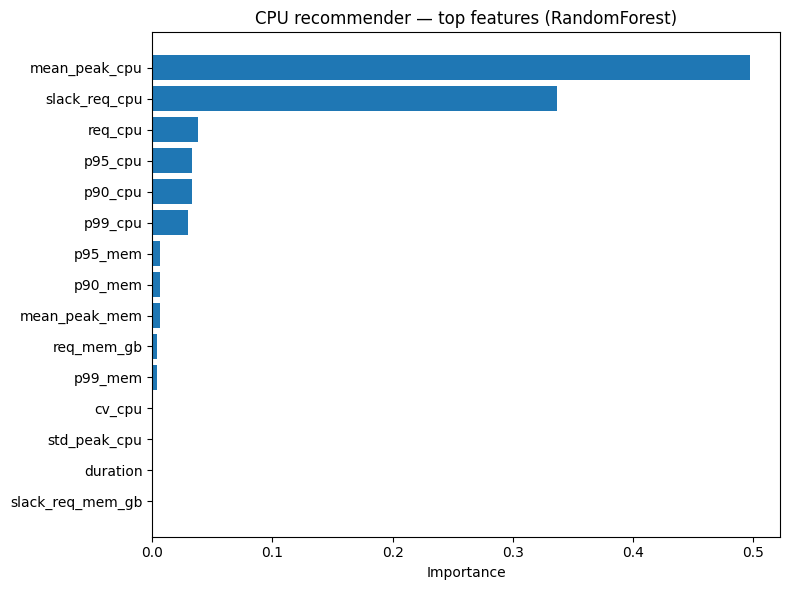

mean_peak_cpu       0.497194
slack_req_cpu       0.336947
req_cpu             0.037934
p95_cpu             0.033410
p90_cpu             0.033214
p99_cpu             0.029813
p95_mem             0.006643
p90_mem             0.006384
mean_peak_mem       0.006216
req_mem_gb          0.004083
p99_mem             0.003986
cv_cpu              0.001022
std_peak_cpu        0.000836
duration            0.000668
slack_req_mem_gb    0.000587
dtype: float64


In [9]:
def plot_importance(model, feature_names, title, out_path, top=15):
    imp = pd.Series(model.feature_importances_, index=feature_names)
    imp = imp.sort_values(ascending=False).head(top)[::-1]

    plt.figure(figsize=(8, 6))
    plt.barh(imp.index, imp.values)
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()
    return imp[::-1]


cpu_imp = plot_importance(
    final_cpu_model, X_train_cpu.columns,
    f"CPU recommender — top features ({cpu_pick['model']})",
    FIG_ML_DIR / "feature_importance_cpu.png",
)
print(cpu_imp)


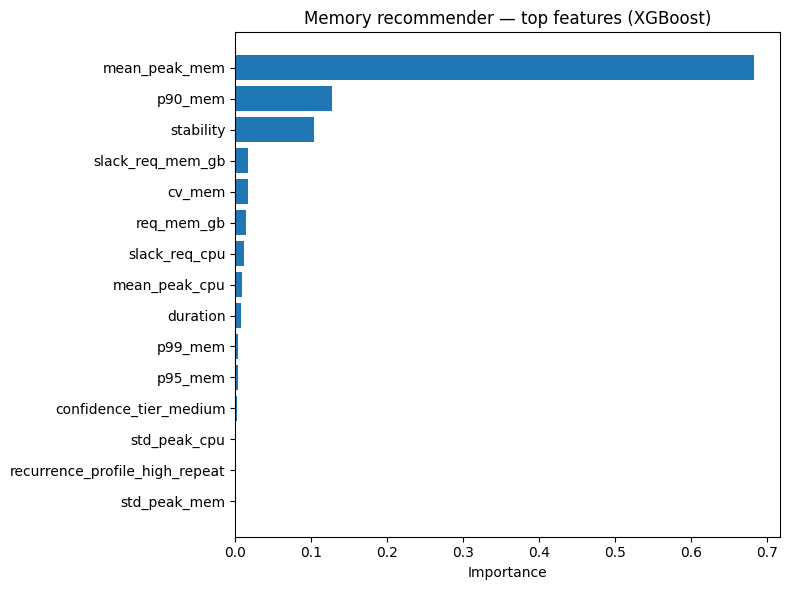

mean_peak_mem                     0.682427
p90_mem                           0.127166
stability                         0.103609
slack_req_mem_gb                  0.016481
cv_mem                            0.016213
req_mem_gb                        0.013538
slack_req_cpu                     0.011087
mean_peak_cpu                     0.008243
duration                          0.007851
p99_mem                           0.003629
p95_mem                           0.002994
confidence_tier_medium            0.002277
std_peak_cpu                      0.000922
recurrence_profile_high_repeat    0.000409
std_peak_mem                      0.000392
dtype: float32


In [10]:
mem_imp = plot_importance(
    final_mem_model, X_train_mem.columns,
    "Memory recommender — top features (XGBoost)",
    FIG_ML_DIR / "feature_importance_mem.png",
)
print(mem_imp)


## 7. Developer-facing recommendation simulation

This is the deployment-style output. Given a single job's metadata + recent
history, TraceAdvisor produces:

- a **recommended CPU** and **recommended memory**, taken as the safer of
  the ML forecast and a conservative historical safeguard (`p95`),
- a **confidence tier** derived from how stable the job's history is
  (run count + coefficient of variation),
- an **expected violation risk** label, computed from the gap between the
  recommendation and the historical p99.

The same logic is applied row-by-row to the test split so we can also report
aggregate CPU/memory violation and waste numbers.


In [11]:
def safe_col(df, col, default=np.nan):
    return df[col] if col in df.columns else pd.Series(default, index=df.index)


def confidence_tier(run_count, cv):
    """Confidence in the recommendation, derived from history depth + variance.
    Sample size dominates; high variance only downgrades, never upgrades.
    """
    rc = 0 if pd.isna(run_count) else float(run_count)
    cvv = float("inf") if pd.isna(cv) else float(cv)
    if rc >= 30 and cvv < 0.5:
        return "High"
    if rc >= 30:
        return "Medium"
    if rc >= 10 and cvv < 0.75:
        return "Medium"
    if rc >= 5:
        return "Low"
    return "Low"


def violation_risk(rec, p95, p99):
    """Risk that the next run exceeds the recommendation.

    Anchored on p95 (the realistic-case threshold) rather than p99,
    because rec = max(ml_pred, p95) by construction — comparing against
    p99 would systematically inflate the "High" label.
    """
    if pd.isna(rec) or rec == 0:
        return "Unknown"
    if pd.isna(p95) or p95 <= 0:
        return "Unknown"
    margin = (rec - p95) / p95
    if margin >= 0.10:
        return "Low"
    if margin >= 0.0:
        return "Medium"
    return "High"


def recommend_for_split(df, X_cpu, X_mem):
    out = df.copy()
    out["ml_pred_cpu"] = final_cpu_model.predict(X_cpu)
    out["ml_pred_mem_gb"] = final_mem_model.predict(X_mem)

    p95_cpu = safe_col(out, "p95_cpu")
    p99_cpu = safe_col(out, "p99_cpu")
    p95_mem = safe_col(out, "p95_mem")
    p99_mem = safe_col(out, "p99_mem")

    out["rec_cpu"] = np.maximum(out["ml_pred_cpu"], p95_cpu.fillna(out["ml_pred_cpu"]))
    out["rec_mem_gb"] = np.maximum(out["ml_pred_mem_gb"], p95_mem.fillna(out["ml_pred_mem_gb"]))

    out["rec_cpu"] = out["rec_cpu"].clip(lower=0)
    out["rec_mem_gb"] = out["rec_mem_gb"].clip(lower=0)

    run_count = safe_col(out, "run_count", 0)
    cv_cpu_col = safe_col(out, "cv_cpu")
    cv_mem_col = safe_col(out, "cv_mem")

    out["confidence_cpu"] = [confidence_tier(rc, cv) for rc, cv in zip(run_count, cv_cpu_col)]
    out["confidence_mem"] = [confidence_tier(rc, cv) for rc, cv in zip(run_count, cv_mem_col)]
    out["violation_risk_cpu"] = [
        violation_risk(r, p95, p99)
        for r, p95, p99 in zip(out["rec_cpu"], p95_cpu, p99_cpu)
    ]
    out["violation_risk_mem"] = [
        violation_risk(r, p95, p99)
        for r, p95, p99 in zip(out["rec_mem_gb"], p95_mem, p99_mem)
    ]

    return out


test_recs = recommend_for_split(test_df, X_test_cpu, X_test_mem)
display(test_recs[[
    "recurrence_key", "run_count",
    "req_cpu", "rec_cpu", "peak_cpu",
    "req_mem_gb", "rec_mem_gb", "peak_mem_gb",
    "confidence_cpu", "violation_risk_cpu",
    "confidence_mem", "violation_risk_mem",
]].head(10))


,recurrence_key,run_count,req_cpu,rec_cpu,peak_cpu,req_mem_gb,rec_mem_gb,peak_mem_gb,confidence_cpu,violation_risk_cpu,confidence_mem,violation_risk_mem
0,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
1,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
2,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
3,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
4,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
5,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
6,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
7,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
8,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium
9,ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+Gj/D4YUMRFDU=||...,257.0,0.008102,0.001244,0.000818,0.003613,0.000743,0.000679,Medium,Medium,High,Medium


In [12]:
def policy_metrics(df, actual_col, rec_col):
    tmp = df[[actual_col, rec_col]].dropna()
    if len(tmp) == 0:
        return {}
    actual = tmp[actual_col]
    rec = tmp[rec_col]
    slack = rec - actual
    return {
        "rows": len(tmp),
        "violation_rate": float((actual > rec).mean()),
        "coverage":       float((actual <= rec).mean()),
        "avg_slack":      float(slack.mean()),
        "avg_overprovision":  float(slack.clip(lower=0).mean()),
        "avg_underprovision": float((-slack).clip(lower=0).mean()),
        "mae":            float(slack.abs().mean()),
    }


final_summary = pd.DataFrame([
    {"resource": "cpu", **policy_metrics(test_recs, "peak_cpu", "rec_cpu")},
    {"resource": "mem", **policy_metrics(test_recs, "peak_mem_gb", "rec_mem_gb")},
    # for reference: as-is
    {"resource": "cpu_as_is", **policy_metrics(test_recs, "peak_cpu", "req_cpu")},
    {"resource": "mem_as_is", **policy_metrics(test_recs, "peak_mem_gb", "req_mem_gb")},
])
final_summary.to_csv(TABLE_DIR / "final_recommender_test_v0.csv", index=False, float_format="%.6f")
display(final_summary)


,resource,rows,violation_rate,coverage,avg_slack,avg_overprovision,avg_underprovision,mae
0,cpu,10762,0.328563,0.671437,0.012680,0.015494,0.002814,0.018308
1,mem,10762,0.331630,0.668370,0.000613,0.001362,0.000749,0.002112
2,cpu_as_is,10762,0.436908,0.563092,-0.007372,0.005289,0.012661,0.017950
3,mem_as_is,10762,0.105092,0.894908,0.011032,0.012018,0.000986,0.013004


### 7a. Worked example — what a developer would see

Pick one row from the test split with enough history and render the
recommendation the way it would appear in the TraceAdvisor CLI / UI.


In [13]:
def render_recommendation(row):
    based_on = int(row.get("run_count", 0) or 0)
    key = str(row.get("recurrence_key", "<unknown>"))
    key_short = (key[:32] + "…") if len(key) > 33 else key
    return (
        f"TraceAdvisor recommendation for job: {key_short}\n"
        f"  Recommended CPU   : {row['rec_cpu']:.4f}    "
        f"(historical p95 = {row.get('p95_cpu', float('nan')):.4f})\n"
        f"  Recommended Memory: {row['rec_mem_gb']:.4f} GB "
        f"(historical p95 = {row.get('p95_mem', float('nan')):.4f} GB)\n"
        f"  Confidence (CPU/Mem): {row['confidence_cpu']} / {row['confidence_mem']}\n"
        f"  Expected violation risk (CPU/Mem): "
        f"{row['violation_risk_cpu']} / {row['violation_risk_mem']}\n"
        f"  Based on: {based_on} prior runs"
    )


# Pick one row per distinct recurring job, then sample one — avoids the
# "all 10 rows are the same job" effect from the test split being grouped.
candidates = test_recs[test_recs["run_count"].fillna(0) >= 5]
if len(candidates):
    demo_row = (
        candidates.drop_duplicates("recurrence_key")
                  .sample(1, random_state=42)
                  .iloc[0]
    )
else:
    demo_row = test_recs.iloc[0]
print(render_recommendation(demo_row))


TraceAdvisor recommendation for job: ly4HE4d+6E8BqXgm6E1eGNKu8OiiZE+G…
  Recommended CPU   : 0.0719    (historical p95 = 0.0719)
  Recommended Memory: 0.0013 GB (historical p95 = 0.0010 GB)
  Confidence (CPU/Mem): Low / Medium
  Expected violation risk (CPU/Mem): Medium / Low
  Based on: 18 prior runs


## 7b. Paper-style CPU metrics — ML Only vs Hybrid

CPU-only summary using the metric definitions from the paper:

- **Safety (%)** — share of jobs where the recommendation covered the realised peak.
- **Violation (%)** — complement of Safety; share of under-provisioned jobs.
- **Efficiency / Utilization (%)** — `mean(actual / recommended) × 100`.
  Higher means tighter recommendations; values close to 100% are good provided
  Violation stays acceptable.

*ML Only* uses the raw regressor output. *Hybrid* is the final TraceAdvisor
recommendation `max(ML, p95)`.

In [17]:
def table_metrics(actual, recommended):
    tmp = pd.DataFrame({"actual": actual, "recommended": recommended}).dropna()
    tmp = tmp[tmp["recommended"] > 0]
    if len(tmp) == 0:
        return float("nan"), float("nan"), float("nan"), float("nan")

    violation = (tmp["actual"] > tmp["recommended"]).mean() * 100
    safety = 100 - violation

    ratio = tmp["actual"] / tmp["recommended"]
    util_capped = ratio.clip(upper=1.0).mean() * 100   # bounded 0–100, "fully-used %"
    util_median = ratio.median() * 100                  # robust to outliers

    return safety, violation, util_capped, util_median


ml_safety, ml_violation, ml_util, ml_util_med = table_metrics(
    test_recs["peak_cpu"], test_recs["ml_pred_cpu"]
)
hybrid_safety, hybrid_violation, hybrid_util, hybrid_util_med = table_metrics(
    test_recs["peak_cpu"], test_recs["rec_cpu"]
)

traceadvisor_rows = pd.DataFrame([
    {
        "Workload": "TraceAdvisor",
        "Method": "ML Only",
        "Safety (%)": round(ml_safety, 1),
        "Violation (%)": round(ml_violation, 1),
        "Utilization capped (%)": round(ml_util, 1),
        "Utilization median (%)": round(ml_util_med, 1),
    },
    {
        "Workload": "TraceAdvisor",
        "Method": "Hybrid",
        "Safety (%)": round(hybrid_safety, 1),
        "Violation (%)": round(hybrid_violation, 1),
        "Utilization capped (%)": round(hybrid_util, 1),
        "Utilization median (%)": round(hybrid_util_med, 1),
    },
])

traceadvisor_rows.to_csv(
    TABLE_DIR / "traceadvisor_cpu_metrics_v0.csv", index=False
)
display(traceadvisor_rows)

,Workload,Method,Safety (%),Violation (%),Utilization capped (%),Utilization median (%)
0,TraceAdvisor,ML Only,53.7,46.3,80.2,98.5
1,TraceAdvisor,Hybrid,68.2,31.8,56.7,61.9


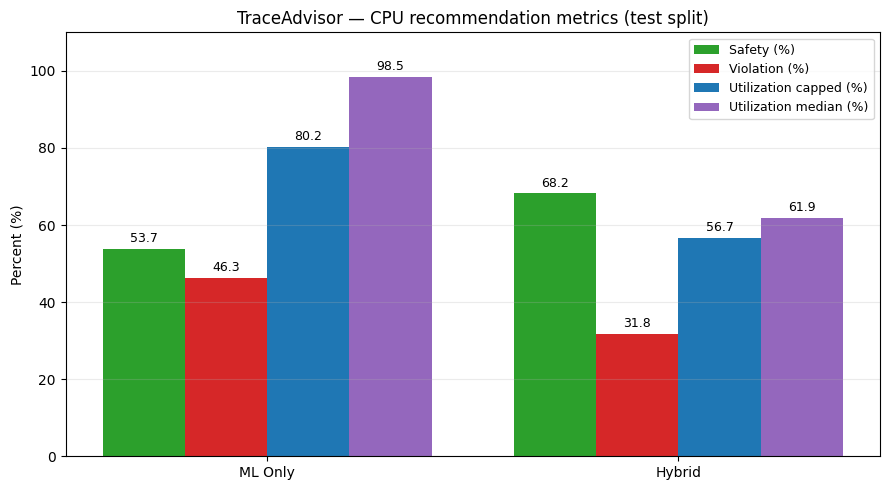

Saved: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/figures_ml/traceadvisor_cpu_metrics.png


In [18]:
methods = traceadvisor_rows["Method"].tolist()
metrics = ["Safety (%)", "Violation (%)", "Utilization capped (%)", "Utilization median (%)"]

x = np.arange(len(methods))
width = 0.2
colors = ["#2ca02c", "#d62728", "#1f77b4", "#9467bd"]

fig, ax = plt.subplots(figsize=(9, 5))
for i, (metric, color) in enumerate(zip(metrics, colors)):
    vals = traceadvisor_rows[metric].tolist()
    bars = ax.bar(x + (i - 1.5) * width, vals, width, label=metric, color=color)
    for b, v in zip(bars, vals):
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1,
                f"{v:.1f}", ha="center", va="bottom", fontsize=9)

ax.set_xticks(x)
ax.set_xticklabels(methods)
ax.set_ylabel("Percent (%)")
ax.set_ylim(0, 110)                # bounded 0–100, no more 1317% spike
ax.set_title("TraceAdvisor — CPU recommendation metrics (test split)")
ax.legend(loc="upper right", fontsize=9)
ax.grid(axis="y", alpha=0.25)

out_chart = FIG_ML_DIR / "traceadvisor_cpu_metrics.png"
plt.tight_layout()
plt.savefig(out_chart, dpi=200, bbox_inches="tight")
plt.show()
plt.close()
print("Saved:", out_chart)

## 8. Persist final recommendations
print("Wrote:", TABLE_DIR / "traceadvisor_cpu_metrics_v0.csv")
print("Wrote:", FIG_ML_DIR / "traceadvisor_cpu_metrics.png")


In [16]:
out_path = DATA_PROCESSED / "job_metrics_test_with_final_recommendations_v0.parquet"
test_recs.to_parquet(out_path, index=False)
print("Wrote:", out_path)
print("Wrote:", TABLE_DIR / "ml_tuning_summary_v0.csv")
print("Wrote:", TABLE_DIR / "ml_cv_summary_v0.csv")
print("Wrote:", TABLE_DIR / "final_recommender_test_v0.csv")
print("Wrote:", FIG_ML_DIR / "feature_importance_cpu.png")
print("Wrote:", FIG_ML_DIR / "feature_importance_mem.png")


Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/data/processed/job_metrics_test_with_final_recommendations_v0.parquet
Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/tables/ml_tuning_summary_v0.csv
Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/tables/ml_cv_summary_v0.csv
Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/tables/final_recommender_test_v0.csv
Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/figures_ml/feature_importance_cpu.png
Wrote: /content/drive/Shareddrives/CMPE 295A_B/subset/reports/eval/subset/figures_ml/feature_importance_mem.png


## 9. Conclusions

- **Tuning** improved the validation RMSE of the Subset-05 strongest models on
  both CPU and memory (see `ml_tuning_summary_v0.csv`).
- **Cross-validation** with `TimeSeriesSplit` and `GroupKFold` confirms that
  the tuned models are stable across folds — variance across folds is
  reported in `ml_cv_summary_v0.csv` and is small relative to the mean RMSE,
  so single-split numbers from Subset-05 were not overstated.
- **Final lock-in** picks the best validated model per resource and refits
  it on the full training set.
- **Feature importance** charts show that historical features
  (`p95`, `p99`, `mean_peak`, `cv`, `run_count`, `duration`) carry the
  signal — the model is not just echoing the user's `req_cpu`/`req_mem`.
- **Developer-facing simulation** turns each recommendation into a
  human-readable block with confidence and violation-risk labels, which is
  the contract the rest of TraceAdvisor (CLI / UI) consumes.
